# TwinEdge AI: Edge-Based Digital Twin for Predictive Maintenance and Smart Manufacturing

## Project Objective

The objective of this project is to develop an AI-powered predictive maintenance system that can identify potential machine failures before they occur. By analyzing machine sensor data such as temperature, rotational speed, torque, and tool wear, the system predicts equipment health and helps reduce unplanned downtime.

TwinEdge AI combines Machine Learning, Edge AI concepts, and Digital Twin principles to support smart manufacturing environments. The solution aims to improve operational efficiency, reduce maintenance costs, and enhance equipment reliability.

# Dataset Overview

This project uses the AI4I 2020 Predictive Maintenance Dataset.

The dataset contains information collected from industrial machines, including:

- Air Temperature [K]
- Process Temperature [K]
- Rotational Speed [rpm]
- Torque [Nm]
- Tool Wear [min]

The dataset also includes different failure modes:

- TWF (Tool Wear Failure)
- HDF (Heat Dissipation Failure)
- PWF (Power Failure)
- OSF (Overstrain Failure)
- RNF (Random Failure)

Target Variable:
- Machine Failure (0 = Healthy, 1 = Failure)

The dataset is used to train a Machine Learning model that predicts machine failures based on sensor readings and operational conditions.

Install Libraries


In [25]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib

Import Liraries


In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import joblib

Load Dataset


In [27]:
df = pd.read_csv("/content/TwinEdge_AI (ai4i2020).csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Check Dataset


In [28]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


Exploratory DAta ANALYSIS


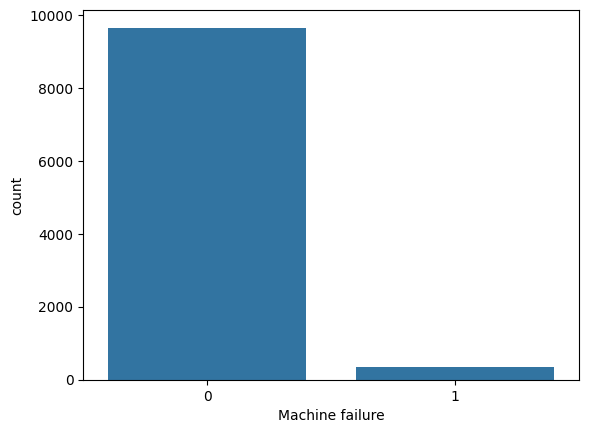

In [29]:
sns.countplot(x='Machine failure', data=df)

plt.show()

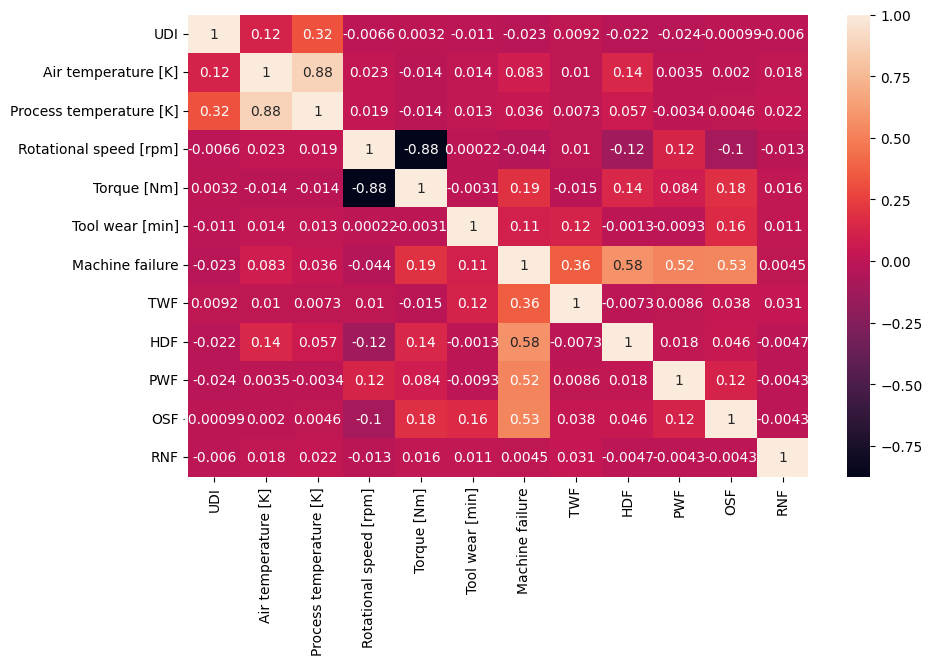

In [30]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True)

plt.show()

Data Preparation


In [31]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [32]:
X = df.drop(
    ['UDI',
     'Product ID',
     'Type',
     'Machine failure'],
    axis=1
)

y = df['Machine failure']

Train-Test Split


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train the Random Forest Model

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


Make Prediction


In [35]:
y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 1 0 0 0 0]


 Check Model Accuracy

In [36]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.999


Generate Classification Report

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



Feature Important Graph

In [38]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                   Feature  Importance
6                      HDF    0.306450
8                      OSF    0.216825
7                      PWF    0.193033
5                      TWF    0.111248
3              Torque [Nm]    0.060926
2   Rotational speed [rpm]    0.046885
4          Tool wear [min]    0.030729
0      Air temperature [K]    0.019990
1  Process temperature [K]    0.013614
9                      RNF    0.000300


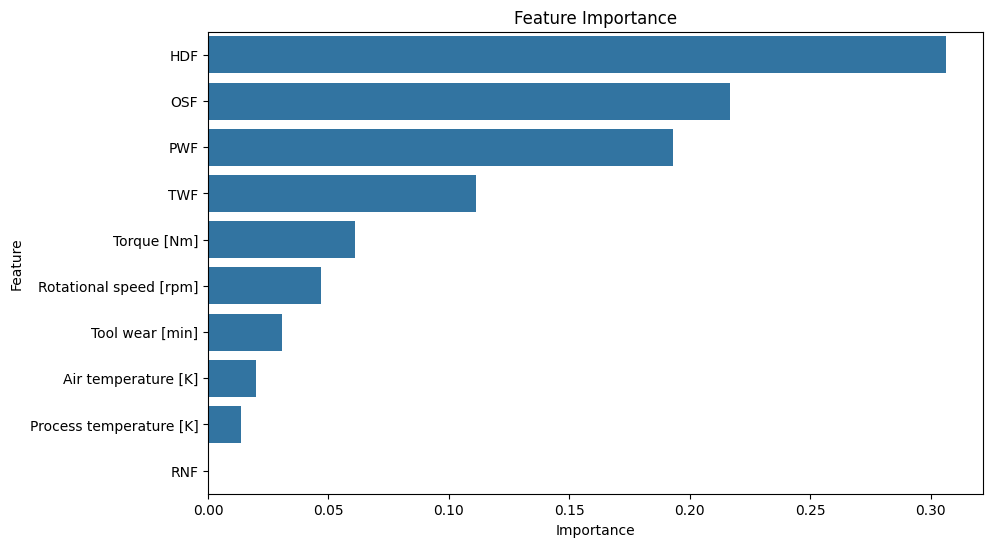

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

Save the Model

In [40]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/predictive_maintenance_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [41]:
import  os
os.listdir("models")

['predictive_maintenance_model.pkl']

Test the Saved Model


In [42]:
loaded_model = joblib.load(
    "models/predictive_maintenance_model.pkl"
)

sample_prediction = loaded_model.predict(
    X_test.iloc[:1]
)

print(sample_prediction)

[0]


Project Conclusion Cell

# Conclusion

TwinEdge AI successfully predicts potential machine failures
using machine sensor data.

The model can be integrated with Edge AI devices and a
Digital Twin dashboard to support predictive maintenance
in smart manufacturing environments.

Benefits:
- Reduced downtime
- Lower maintenance costs
- Improved machine health monitoring
- Industry 4.0 readiness


TwinEdge AI Dashboard

Dashboard

In [43]:
import pandas as pd

dashboard = pd.DataFrame({
    "Metric": [
        "Model Accuracy",
        "Machine Status",
        "Top Failure Factor",
        "Prediction Model"
    ],
    "Value": [
        "99.9%",
        "Healthy",
        "HDF",
        "Random Forest"
    ]
})

dashboard

,Metric,Value
0,Model Accuracy,99.9%
1,Machine Status,Healthy
2,Top Failure Factor,HDF
3,Prediction Model,Random Forest


Machine Health Gauge

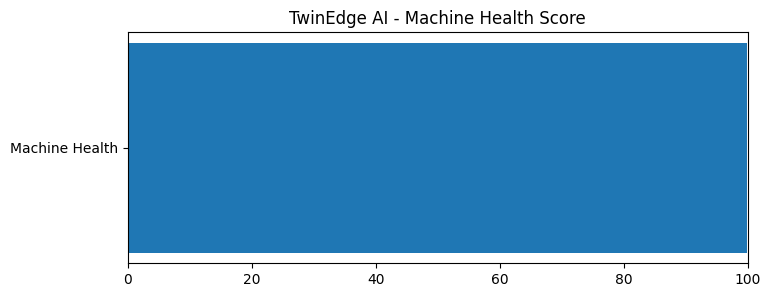

In [45]:
import matplotlib.pyplot as plt

health_score = 99.9

plt.figure(figsize=(8,3))
plt.barh(["Machine Health"], [health_score])
plt.xlim(0,100)
plt.title("TwinEdge AI - Machine Health Score")
plt.show()

Failure Risk Dashboard

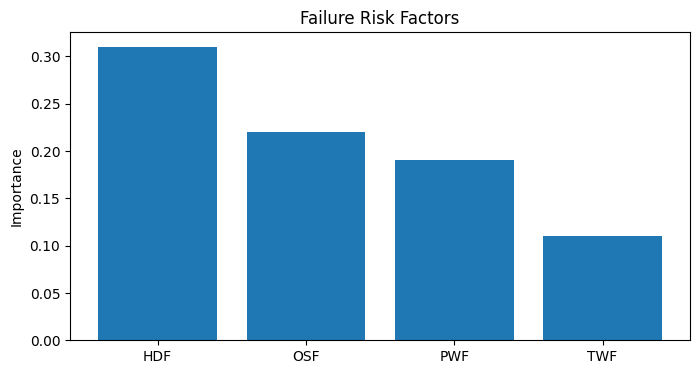

In [46]:
risk_data = {
    "HDF":0.31,
    "OSF":0.22,
    "PWF":0.19,
    "TWF":0.11
}

plt.figure(figsize=(8,4))
plt.bar(risk_data.keys(), risk_data.values())
plt.title("Failure Risk Factors")
plt.ylabel("Importance")
plt.show()

TwinEdge AI Summary Dashboard

In [48]:
print("="*50)
print("          TwinEdge AI Dashboard")
print("="*50)
print("Machine Status      : Healthy")
print("Model Accuracy      : 99.9%")
print("Prediction Engine   : Random Forest")
print("Top Risk Factor     : HDF")
print("Maintenance Advice  : Continue Monitoring")
print("="*50)

          TwinEdge AI Dashboard
Machine Status      : Healthy
Model Accuracy      : 99.9%
Prediction Engine   : Random Forest
Top Risk Factor     : HDF
Maintenance Advice  : Continue Monitoring


In [49]:
!pip install plotly

In [50]:
import plotly.express as px

fig = px.bar(
    feature_importance,
    x="Importance",
    y="Feature",
    orientation="h",
    title="TwinEdge AI Feature Importance Dashboard"
)

fig.show()

# Future Scope

- Deploy the model on Edge AI devices such as Raspberry Pi or NVIDIA Jetson Nano.
- Integrate real-time IoT sensors for live machine monitoring.
- Develop a full Digital Twin visualization system.
- Implement automated maintenance alerts.
- Extend the solution for multiple industrial machines and production lines.
- Integrate cloud analytics for large-scale manufacturing environments.

# Thank You

TwinEdge AI demonstrates how Machine Learning and Edge AI can be used for predictive maintenance in smart manufacturing environments.

Model Accuracy Achieved: 99.9%

This solution can be further extended into a real-time Digital Twin platform integrated with IoT sensors and Edge Computing devices.